# BB84 QKD Simulator — Results & Analysis
**University of Ruhuna — Dept. of Computer Engineering**

This notebook reproduces all figures and tables for the research report.  
Each section follows the pattern:
1. **Collect** — run the simulations, store raw data  
2. **Plot**   — call the plot function on stored data (re-run without re-simulating)

---
| Figure | Experiment | Key insight |
|--------|-----------|-------------|
| A | QBER vs qubit count *n* | CI narrows as $1/\sqrt{n}$ |
| B | QBER vs Eve intercept (multi-*n*) | Linear QBER–$p$ relationship |
| C | Sample fraction effect | Optimal fraction trade-off |
| D | Depolar × Eve heatmap | Noise masks Eve below 5 % |
| E | Depolar × Eve line plot | Additive noise floor |
| F | Detection probability vs *n* | Reliability threshold at *n* |


---
## Cell 0 — Imports & Setup

In [65]:
import importlib, sys, warnings
warnings.filterwarnings('ignore')

# ── Fresh reload ──────────────────────────────────────────────────────
for mod in list(sys.modules.keys()):
    if 'bb84' in mod:
        sys.modules.pop(mod)
importlib.invalidate_caches()

from bb84_config import SimulationConfig
from bb84_runner import run_simulation
from bb84_plots_extended import (
    # Data collectors
    collect_sample_size_data,
    collect_intercept_sweep_data,
    collect_sample_fraction_data,
    collect_depolar_eve_data,
    # Plot functions
    plot_sample_size_sensitivity,
    plot_qber_vs_intercept_enhanced,
    plot_sample_fraction_effect,
    plot_depolar_vs_eve_heatmap,
    plot_depolar_vs_eve_lines,
    plot_detection_power,
    collect_detection_power_data
)

print('[✓] All imports OK')

[✓] All imports OK


---
## Figure A — Effect of Qubit Count on QBER Estimation

**Research question:** How many qubits are needed for stable QBER estimation?  
We compare *n* = 10, 50, 100, 300, 600, 1 000 under ideal conditions and Eve-100 %.

> **Expected:** CI width ∝ 1/√(n × sample_fraction).  
> Small *n* → wide CI → unreliable ABORT/SECURE decision.

In [15]:
# ── A-1: COLLECT ──────────────────────────────────────────────────────
N_VALUES = [10, 50, 100, 300, 600, 1000]

print('=== Ideal channel (no Eve) ===')
data_A_ideal  = collect_sample_size_data(N_VALUES, eve_intercept=0.0,
                                          sample_fraction=0.15, seed=42)

print('\n=== Eve full intercept (100 %) ===')
data_A_eve100 = collect_sample_size_data(N_VALUES, eve_intercept=1.0,
                                          sample_fraction=0.15, seed=42)

=== Ideal channel (no Eve) ===


KeyboardInterrupt: 

  [✓] Saved → fig_A_sample_size.png  (300 dpi)


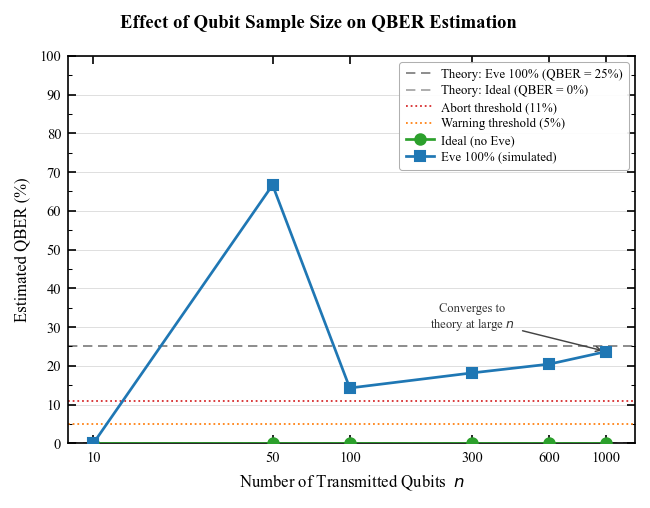

In [61]:
# ── A-2: PLOT ─────────────────────────────────────────────────────────
plot_sample_size_sensitivity(
    data_ideal  = data_A_ideal,
    data_eve100 = data_A_eve100,
    n_values    = N_VALUES,
    save_path   = 'fig_A_sample_size.png',
)

  [✓] Saved → fig_A2_ci_width.png  (300 dpi)


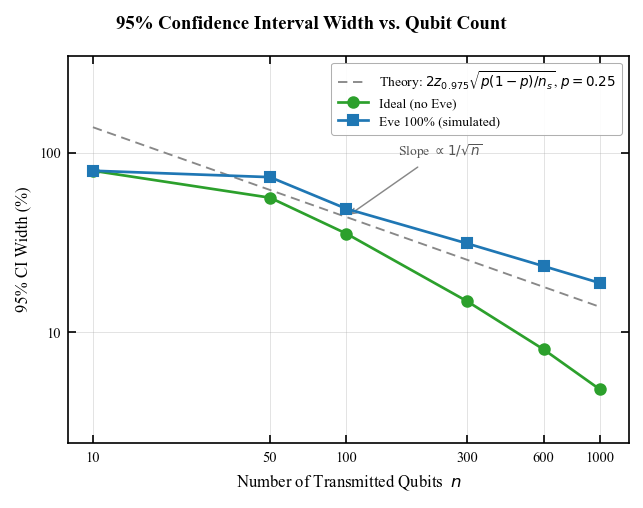

In [62]:
from bb84_plots_extended import plot_ci_width_vs_n

# Uses data_A_ideal and data_A_eve100 already collected in Cell A-1
plot_ci_width_vs_n(
    data_ideal       = data_A_ideal,
    data_eve100      = data_A_eve100,
    n_values         = N_VALUES,
    sample_fraction  = 0.15,
    save_path        = "fig_A2_ci_width.png",
)

**Table A — Raw values (copy to paper)**

In [27]:
print(f"{'n':>6}  {'QBER_ideal':>10}  {'CI_ideal':>18}  {'QBER_eve':>10}  {'CI_eve':>18}")
print('-' * 72)
for di, de in zip(data_A_ideal, data_A_eve100):
    n = di['n']
    print(f"{n:>6}  {di['qber']:>9.1f}%  "
          f"[{di['ci_low']:>5.1f}, {di['ci_high']:>5.1f}]  "
          f"{de['qber']:>9.1f}%  "
          f"[{de['ci_low']:>5.1f}, {de['ci_high']:>5.1f}]")

     n  QBER_ideal            CI_ideal    QBER_eve              CI_eve
------------------------------------------------------------------------
    10        0.0%  [  0.0,  79.3]        0.0%  [  0.0,  79.3]
    50        0.0%  [  0.0,  56.2]       66.7%  [ 20.8,  93.9]
   100        0.0%  [  0.0,  35.4]       14.3%  [  2.6,  51.3]
   300        0.0%  [  0.0,  14.9]       18.2%  [  7.3,  38.5]
   600        0.0%  [  0.0,   8.0]       20.5%  [ 11.2,  34.5]
  1000        0.0%  [  0.0,   4.8]       23.7%  [ 15.5,  34.4]


---
## Figure B — QBER vs. Eve Intercept Probability (Multi-n)

**Research question:** Does larger *n* converge better toward the theoretical QBER = 0.25 × p_Eve?  
We sweep p_Eve: 0 % → 100 % (11 steps) for n = 100, 300, 600, 1 000.

> **Theory:** Intercept-resend attack → QBER = 0.25 × p_Eve  
> Deviation at small *n* is due to sampling variance.

In [ ]:
# ── B-1: COLLECT ──────────────────────────────────────────────────────
N_LIST_B = [40, 400, 600, 1000]
STEPS_B  = 10

sweep_data_B = {}
for n in N_LIST_B:
    print(f'\n--- n = {n} ---')
    sweep_data_B[n] = collect_intercept_sweep_data(
        n_qubits=n, steps=STEPS_B, sample_fraction=0.15, seed=42
    )


--- n = 40 ---
    p=0.00  QBER=0.0%
    p=0.10  QBER=0.0%
    p=0.20  QBER=0.0%
    p=0.30  QBER=33.3%
    p=0.40  QBER=33.3%
    p=0.50  QBER=0.0%
    p=0.60  QBER=0.0%
    p=0.70  QBER=0.0%
    p=0.80  QBER=0.0%
    p=0.90  QBER=66.7%
    p=1.00  QBER=66.7%

--- n = 100 ---
    p=0.00  QBER=0.0%
    p=0.10  QBER=0.0%
    p=0.20  QBER=0.0%
    p=0.30  QBER=0.0%
    p=0.40  QBER=0.0%
    p=0.50  QBER=0.0%
    p=0.60  QBER=0.0%
    p=0.70  QBER=0.0%
    p=0.80  QBER=0.0%
    p=0.90  QBER=0.0%
    p=1.00  QBER=14.3%

--- n = 400 ---
    p=0.00  QBER=0.0%
    p=0.10  QBER=3.2%
    p=0.20  QBER=6.5%
    p=0.30  QBER=3.2%
    p=0.40  QBER=12.9%
    p=0.50  QBER=6.5%
    p=0.60  QBER=9.7%
    p=0.70  QBER=12.9%
    p=0.80  QBER=12.9%
    p=0.90  QBER=16.1%
    p=1.00  QBER=16.1%

--- n = 600 ---
    p=0.00  QBER=0.0%
    p=0.10  QBER=2.3%
    p=0.20  QBER=4.5%
    p=0.30  QBER=6.8%
    p=0.40  QBER=9.1%
    p=0.50  QBER=11.4%
    p=0.60  QBER=13.6%
    p=0.70  QBER=15.9%
    p=0.80  QBER=1

  [✓] Saved → fig_B_qber_vs_intercept_n40.png  (300 dpi)


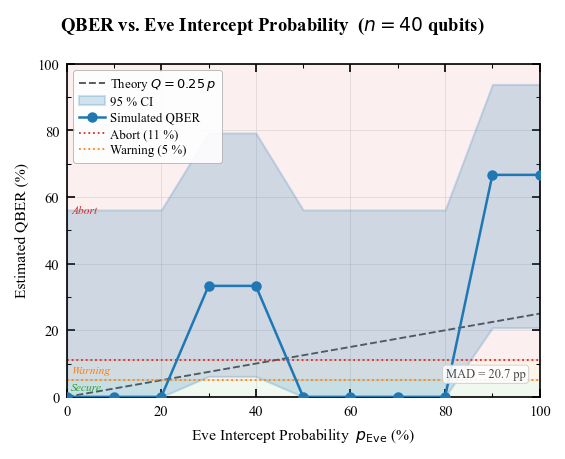

  [✓] Saved → fig_B_qber_vs_intercept_n100.png  (300 dpi)


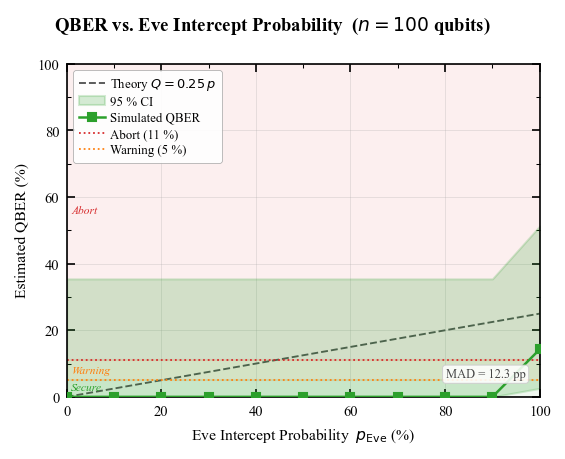

  [✓] Saved → fig_B_qber_vs_intercept_n400.png  (300 dpi)


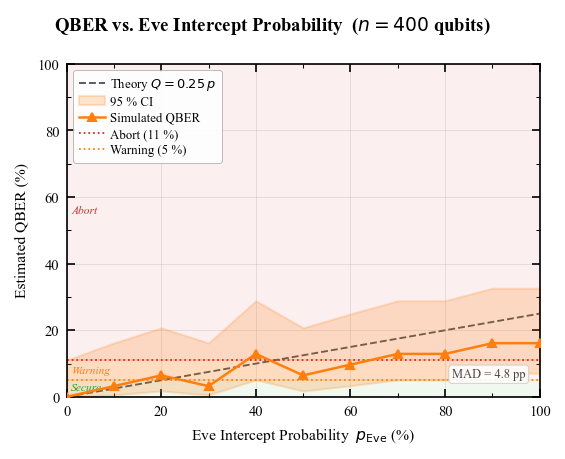

  [✓] Saved → fig_B_qber_vs_intercept_n600.png  (300 dpi)


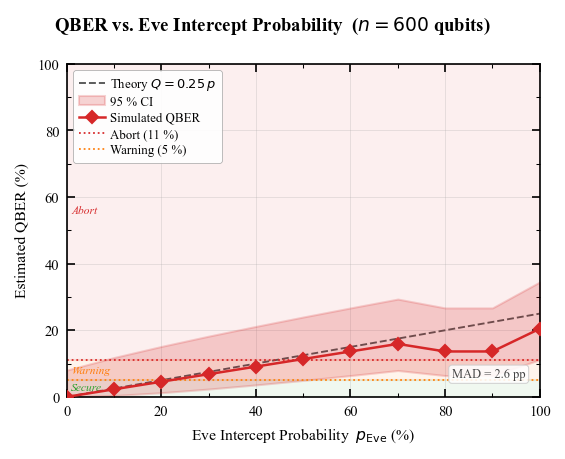

In [63]:
# ── B-2: PLOT ─────────────────────────────────────────────────────────
plot_qber_vs_intercept_enhanced(
    sweep_data = sweep_data_B,
    n_list     = N_LIST_B,
    save_path  = 'fig_B_qber_vs_intercept.png',
)

---
## Figure C — Effect of Sample Fraction on QBER Estimation

**Research question:** What sample fraction gives the best QBER accuracy with minimum key sacrifice?

We test sample fractions: 5 %, 10 %, 15 %, 20 %, 30 %, 45 %  
at four intercept rates: p = 0, 0.3, 0.5, 1.0  (n = 600).

> **Trade-off:** Higher fraction → tighter CI → less final key length.  
> We identify the *knee point* where CI gain saturates.

In [46]:
# ── C-1: COLLECT ──────────────────────────────────────────────────────
INTERCEPT_RATES_C = [0.3, 0.5, 1.0]
FRAC_VALUES_C     = [0.05, 0.10, 0.15, 0.20, 0.3]

print('=== Sample fraction sweep (n=600) ===')
frac_data_C = collect_sample_fraction_data(
    intercept_rates = INTERCEPT_RATES_C,
    frac_values     = FRAC_VALUES_C,
    n_qubits        = 600,
    seed            = 42,
)

=== Sample fraction sweep (n=600) ===
    p=0.30  frac=0.05  QBER=0.0%
    p=0.30  frac=0.10  QBER=3.4%
    p=0.30  frac=0.15  QBER=6.8%
    p=0.30  frac=0.20  QBER=6.8%
    p=0.30  frac=0.30  QBER=4.5%
    p=0.50  frac=0.05  QBER=7.1%
    p=0.50  frac=0.10  QBER=3.4%
    p=0.50  frac=0.15  QBER=11.4%
    p=0.50  frac=0.20  QBER=10.2%
    p=0.50  frac=0.30  QBER=10.1%
    p=1.00  frac=0.05  QBER=14.3%
    p=1.00  frac=0.10  QBER=24.1%
    p=1.00  frac=0.15  QBER=20.5%
    p=1.00  frac=0.20  QBER=23.7%
    p=1.00  frac=0.30  QBER=23.6%


  [✓] Saved → fig_C_sample_fraction.png  (300 dpi)


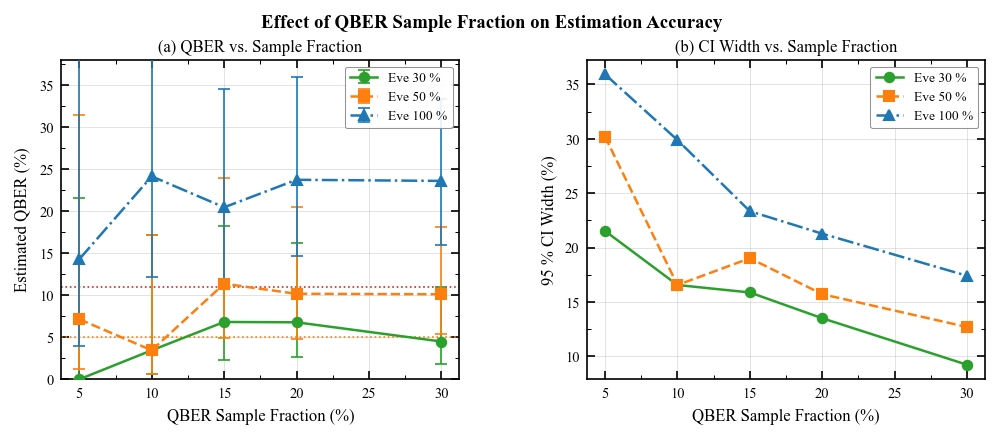

In [56]:
# ── C-2: PLOT ─────────────────────────────────────────────────────────
plot_sample_fraction_effect(
    frac_data       = frac_data_C,
    intercept_rates = INTERCEPT_RATES_C,
    frac_values     = FRAC_VALUES_C,
    save_path       = 'fig_C_sample_fraction.png',
)

**Table C — CI width at each fraction (Eve=100 % — worst case)**

In [48]:
print(f"{'Fraction':>10}  {'QBER (%)':>10}  {'CI_low':>8}  {'CI_high':>8}  {'CI_width':>10}  Status")
print('-' * 65)
for frac in FRAC_VALUES_C:
    d = frac_data_C[1.0][frac]
    w = d['ci_high'] - d['ci_low']
    print(f"  {frac*100:>6.0f} %  {d['qber']:>9.1f}%  {d['ci_low']:>7.1f}%  "
          f"{d['ci_high']:>7.1f}%  {w:>9.1f}%  {d['status']}")

  Fraction    QBER (%)    CI_low   CI_high    CI_width  Status
-----------------------------------------------------------------
       5 %       14.3%      4.0%     39.9%       35.9%  ABORT x
      10 %       24.1%     12.2%     42.1%       29.9%  ABORT x
      15 %       20.5%     11.2%     34.5%       23.3%  ABORT x
      20 %       23.7%     14.7%     36.0%       21.3%  ABORT x
      30 %       23.6%     16.0%     33.4%       17.4%  ABORT x


---
## Figure D & E — Channel Noise × Eve Intercept

**Research question:** How does depolarising channel noise interact with an eavesdropper?  
Can noise *mask* a partial Eve attack below the 5 % warning threshold?

Grid: depolar p ∈ {0, 0.01, 0.03, 0.05} × Eve p ∈ {0, 0.2, 0.4, 0.6, 0.8, 1.0}  (n = 600).

> **Key finding:** At p_dep ≥ 0.03, even a 30 % intercept may stay below 5 % QBER —  
> demonstrating why the noise floor raises the *security margin* requirement.

In [49]:
# ── D/E-1: COLLECT ────────────────────────────────────────────────────
DEPOLAR_VALUES = [0.000, 0.010, 0.030, 0.050]
EVE_VALUES     = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

print('=== Depolar × Eve grid (n=600) ===')
qber_matrix_DE = collect_depolar_eve_data(
    depolar_values  = DEPOLAR_VALUES,
    eve_values      = EVE_VALUES,
    n_qubits        = 600,
    sample_fraction = 0.15,
    seed            = 42,
)

=== Depolar × Eve grid (n=600) ===
    dp=0.000  ep=0.00  QBER=0.0%
    dp=0.000  ep=0.20  QBER=4.5%
    dp=0.000  ep=0.40  QBER=9.1%
    dp=0.000  ep=0.60  QBER=13.6%
    dp=0.000  ep=0.80  QBER=13.6%
    dp=0.000  ep=1.00  QBER=20.5%
    dp=0.010  ep=0.00  QBER=0.0%
    dp=0.010  ep=0.20  QBER=6.8%
    dp=0.010  ep=0.40  QBER=15.9%
    dp=0.010  ep=0.60  QBER=20.5%
    dp=0.010  ep=0.80  QBER=20.5%
    dp=0.010  ep=1.00  QBER=25.0%
    dp=0.030  ep=0.00  QBER=2.3%
    dp=0.030  ep=0.20  QBER=9.1%
    dp=0.030  ep=0.40  QBER=18.2%
    dp=0.030  ep=0.60  QBER=20.5%
    dp=0.030  ep=0.80  QBER=22.7%
    dp=0.030  ep=1.00  QBER=25.0%
    dp=0.050  ep=0.00  QBER=2.3%
    dp=0.050  ep=0.20  QBER=9.1%
    dp=0.050  ep=0.40  QBER=18.2%
    dp=0.050  ep=0.60  QBER=20.5%
    dp=0.050  ep=0.80  QBER=22.7%
    dp=0.050  ep=1.00  QBER=25.0%


  [✓] Saved → fig_D_depolar_heatmap.png  (300 dpi)


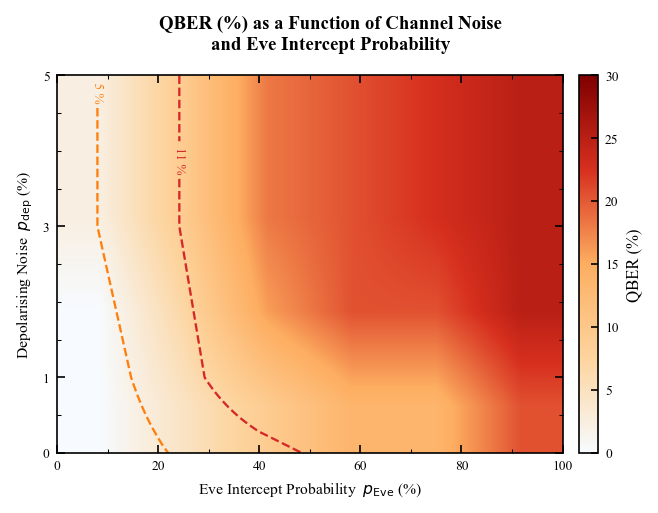

In [64]:
# ── D-2: HEATMAP ──────────────────────────────────────────────────────
plot_depolar_vs_eve_heatmap(
    qber_matrix    = qber_matrix_DE,
    depolar_values = DEPOLAR_VALUES,
    eve_values     = EVE_VALUES,
    save_path      = 'fig_D_depolar_heatmap.png',
)

In [ ]:
# ── E-2: LINE PLOT ────────────────────────────────────────────────────
plot_depolar_vs_eve_lines(
    qber_matrix    = qber_matrix_DE,
    depolar_values = DEPOLAR_VALUES,
    eve_values     = EVE_VALUES,
    save_path      = 'fig_E_depolar_lines.png',
)

**Table D/E — Raw QBER matrix (%)**

In [58]:
import numpy as np
eve_hdr = '  '.join([f'Eve {e*100:.0f}%' for e in EVE_VALUES])
print(f"{'p_dep':>8}   {eve_hdr}")
print('-' * (10 + 10 * len(EVE_VALUES)))
for i, dp in enumerate(DEPOLAR_VALUES):
    row = '  '.join([f"{qber_matrix_DE[i,j]:>7.1f}%" for j in range(len(EVE_VALUES))])
    print(f"  {dp:.3f}   {row}")

   p_dep   Eve 0%  Eve 20%  Eve 40%  Eve 60%  Eve 80%  Eve 100%
----------------------------------------------------------------------
  0.000       0.0%      4.5%      9.1%     13.6%     13.6%     20.5%
  0.010       0.0%      6.8%     15.9%     20.5%     20.5%     25.0%
  0.030       2.3%      9.1%     18.2%     20.5%     22.7%     25.0%
  0.050       2.3%      9.1%     18.2%     20.5%     22.7%     25.0%


---
## Figure F — Eve Detection Probability vs. Qubit Count

**Research question:** What minimum qubit count achieves ≥ 95 % reliable Eve detection?  
We run 20 random-seed trials at each *n*, count ABORT decisions, compute detection rate.

> **Practical recommendation:** The n at which detection first reaches 95 % is the
> *minimum viable qubit budget* for this sample fraction.

In [ ]:
# ── F-1: COLLECT + PLOT (combined — uses internal loop) ───────────────
# Runtime: ~10 trials × 6 n-values × ~1 min/run → may take a few minutes.
# Reduce N_TRIALS to 10 for a quick check.

N_TRIALS   = 10
N_VALUES_F = [50, 100, 200, 400, 600, 1000]

# ── F-1: COLLECT ──────────────────────────────────────────────────────
det_probs = collect_detection_power_data(
    n_values      = N_VALUES_F,
    eve_intercept = 1.0,
    n_trials      = N_TRIALS,
    sample_frac   = 0.15,
)


  [collect_detection_power_data] 10 seeds × 6 n-values …
    n=   50  detection=60.0%  (6/10 trials)
    n=  100  detection=90.0%  (9/10 trials)


In [ ]:
# ── F-2: PLOT ─────────────────────────────────────────────────────────
plot_detection_power(
    n_values     = N_VALUES_F,
    detect_probs = det_probs,
    n_trials     = N_TRIALS,        # subtitle only
    sample_frac  = 0.15,            # subtitle only
    save_path    = 'fig_F_detection_power.png',
)

In [ ]:
# ── F table ───────────────────────────────────────────────────────────
print(f"{'n':>6}  {'Detection (%)':>14}")
print('-' * 25)
for n, dp in zip(N_VALUES_F, det_probs):
    flag = '  ← ≥ 95 % ✓' if dp >= 95 else ''
    print(f"{n:>6}  {dp:>13.1f}%{flag}")

---
## Summary Table — All Key Results

In [ ]:
print('='*70)
print('  RESULTS SUMMARY — BB84 QKD Research Analysis')
print('='*70)

print('\n[A] Min n for stable estimation (CI width < 15 %p at Eve 100 %):')
for d in data_A_eve100:
    flag = ' ← stable' if d['ci_width'] < 15 else ''
    print(f"    n={d['n']:>5d}  CI_width={d['ci_width']:.1f}%{flag}")

print('\n[B] QBER vs Eve at n=1000 (closest to theory):')
probs_B, qbers_B, _, _ = sweep_data_B[1000]
for p, q in zip(probs_B, qbers_B):
    theory = 0.25 * p
    print(f"    p_eve={p:>5.1f}%  QBER={q:>5.1f}%  theory={theory:>5.1f}%  "
          f"delta={abs(q-theory):.1f}%p")

print('\n[C] Optimal sample fraction (Eve 100%, n=600):')
prev_w = 999
for frac in FRAC_VALUES_C:
    d = frac_data_C[1.0][frac]
    w = d['ci_high'] - d['ci_low']
    gain = prev_w - w
    print(f"    frac={frac*100:.0f}%  CI_width={w:.1f}%p  Δgain={gain:.1f}%p")
    prev_w = w

print('\n[D] Noise masking — QBER at Eve=30%, different depolar:')
eve_idx = EVE_VALUES.index(0.2)   # closest to 0.2 = 20%
for i, dp in enumerate(DEPOLAR_VALUES):
    q = qber_matrix_DE[i, eve_idx]
    flag = '  ← below warning' if q < 5 else ''
    print(f"    p_dep={dp:.3f}  QBER(Eve 20%)={q:.1f}%{flag}")

print('\n[F] Minimum n for ≥ 95% detection:')
for n, dp in zip(N_VALUES_F, det_probs):
    if dp >= 95:
        print(f"    → n = {n} achieves {dp:.1f}% detection rate")
        break

print('\n' + '='*70)